In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Project 10: Quality Prediction in Mining Process
## 1. Load and Inspect Data

In [49]:
df = pd.read_csv('mining_flotation.csv')  # adjust filename

# Fix comma decimal separator
for col in df.columns[1:]:  # skip the date column
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print('Fixed. Sample values:')
df.head()

print('Shape:', df.shape)
df.head()

Fixed. Sample values:
Shape: (737453, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


In [50]:
# Check column names, types, missing values
print(df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum().sum())
print('\nData types:')
print(df.dtypes.head(10))

['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']

Missing values:
0

Data types:
date                             object
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Col

## 2. Parse Date and Set Index

In [51]:
# Rename first column to 'date'
df.rename(columns={df.columns[0]: 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print('Date range:', df.index.min(), 'to', df.index.max())
print('Number of timestamps:', len(df))
df.head()

Date range: 2017-03-10 01:00:00 to 2017-09-09 23:00:00
Number of timestamps: 737453


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 3. Explore Target Variable (% Silica Concentrate)

Target: % Silica Concentrate


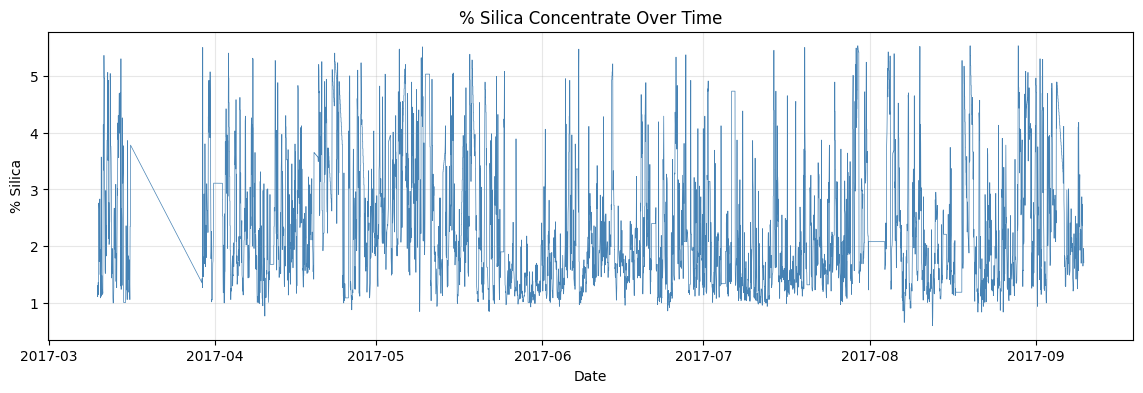

count    737453.000000
mean          2.326763
std           1.125554
min           0.600000
25%           1.440000
50%           2.000000
75%           3.010000
max           5.530000
Name: % Silica Concentrate, dtype: float64


In [52]:
target = df.columns[-1]
print('Target:', target)

plt.figure(figsize=(14, 4))
plt.plot(df.index, df[target], linewidth=0.5, color='steelblue')
plt.title(f'{target} Over Time')
plt.ylabel('% Silica')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.show()

print(df[target].describe())

In [53]:
# Check sampling frequency
time_diffs = df.index.to_series().diff().value_counts().head(10)
print('Most common time intervals:')
print(time_diffs)

Most common time intervals:
date
0 days 00:00:00     733356
0 days 01:00:00       4095
13 days 07:00:00         1
Name: count, dtype: int64


## 4. Correlation Analysis

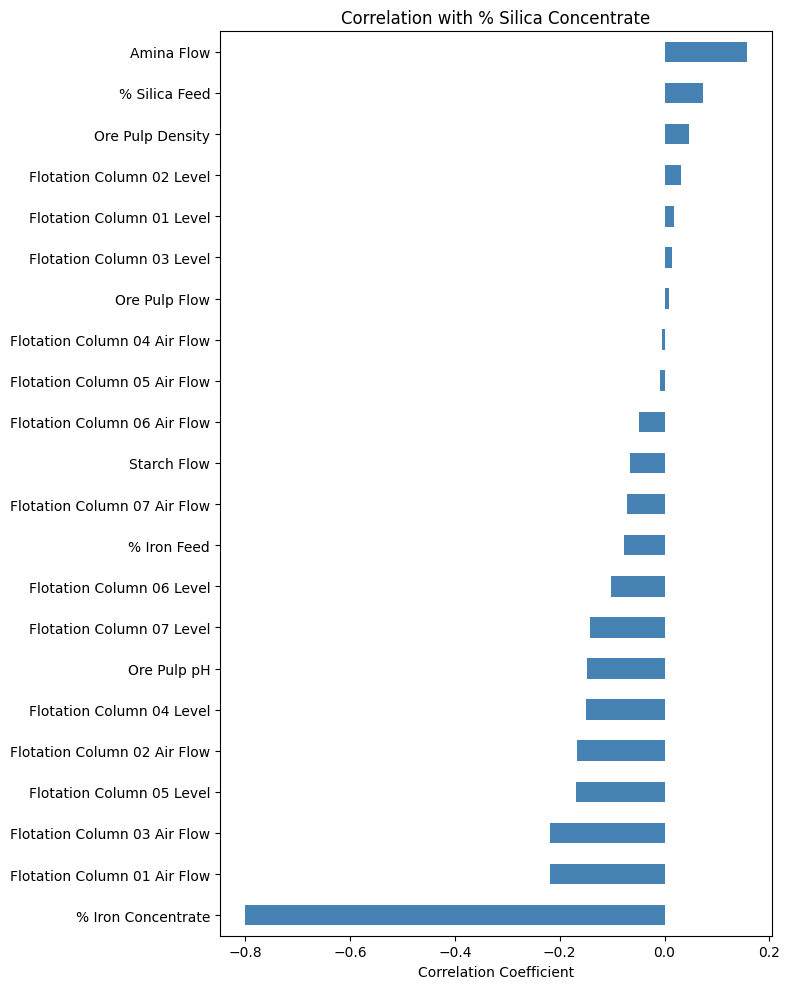

In [54]:
# Correlation with target
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()[target].sort_values()

plt.figure(figsize=(8, 10))
corr.drop(target).plot(kind='barh', color='steelblue')
plt.title('Correlation with % Silica Concentrate')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## 5. Iron Concentrate vs Silica (Key Relationship)

Iron Concentrate column: % Iron Concentrate
Correlation between % Iron Concentrate and % Silica Concentrate: -0.801


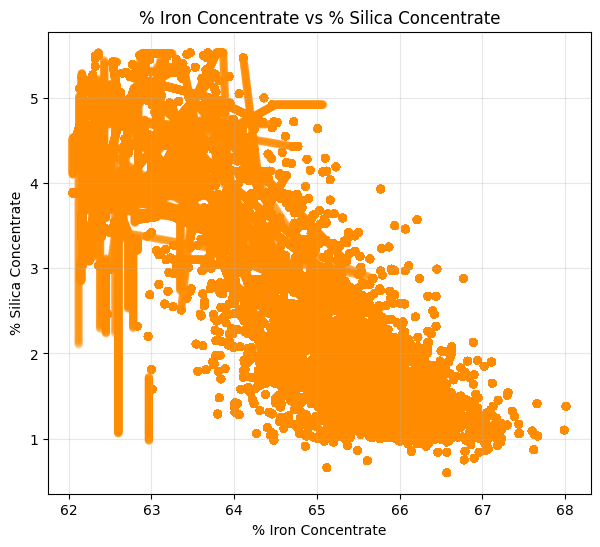

In [55]:
iron_col = df.columns[-2]
print('Iron Concentrate column:', iron_col)
print(f'Correlation between {iron_col} and {target}: {df[iron_col].corr(df[target]):.3f}')

plt.figure(figsize=(7, 6))
plt.scatter(df[iron_col], df[target], alpha=0.3, color='darkorange', edgecolors='none')
plt.xlabel(iron_col)
plt.ylabel(target)
plt.title(f'{iron_col} vs {target}')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Create Lag Features for Time-Series Prediction

In [56]:
# Create lag features for target and iron concentrate
lags = [1, 2, 3, 6, 12]  # hours (try different horizons)

# Lag the target
for lag in lags:
    df[f'{target}_lag_{lag}h'] = df[target].shift(lag)

# Lag iron concentrate
for lag in lags:
    df[f'{iron_col}_lag_{lag}h'] = df[iron_col].shift(lag)

# Drop rows with NaN from lags
df_lagged = df.dropna()
print('Shape before lagging:', df.shape)
print('Shape after lagging:', df_lagged.shape)

Shape before lagging: (737453, 33)
Shape after lagging: (737441, 33)


## 7. Prepare Feature Sets (for three expected questions)

In [57]:
# Set 1: All features including iron concentrate (predict same-time silica)
all_features = [col for col in df_lagged.columns if col != target and not col.startswith(target)]
X_all = df_lagged[all_features]
y = df_lagged[target]

print('Feature set (with Iron):', X_all.shape)

Feature set (with Iron): (737441, 27)


In [58]:
# Set 2: Without iron concentrate (question 3)
no_iron_features = [col for col in all_features if iron_col not in col]
X_no_iron = df_lagged[no_iron_features]

print('Feature set (without Iron):', X_no_iron.shape)

Feature set (without Iron): (737441, 21)


## 8. Train/Test Split (Time-Based)

In [59]:
# Chronological split: first 80% train, last 20% test
split_idx = int(len(df_lagged) * 0.8)
train_data = df_lagged.iloc[:split_idx]
test_data = df_lagged.iloc[split_idx:]

print('Train period:', train_data.index.min(), 'to', train_data.index.max())
print('Test period:', test_data.index.min(), 'to', test_data.index.max())
print('Train size:', len(train_data), '| Test size:', len(test_data))

Train period: 2017-03-10 01:00:00 to 2017-08-06 20:00:00
Test period: 2017-08-06 20:00:00 to 2017-09-09 23:00:00
Train size: 589952 | Test size: 147489


In [60]:
# Prepare train/test matrices for both feature sets
def prepare_data(train, test, feature_cols, target_col):
    X_tr = train[feature_cols]
    y_tr = train[target_col]
    X_te = test[feature_cols]
    y_te = test[target_col]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    return X_tr_scaled, X_te_scaled, y_tr, y_te

# With iron
X_train_all, X_test_all, y_train, y_test = prepare_data(train_data, test_data, all_features, target)

# Without iron
X_train_noiron, X_test_noiron, _, _ = prepare_data(train_data, test_data, no_iron_features, target)

## 9. Model 1: With Iron Concentrate

In [61]:
# Sample if dataset is large (for faster training)
if len(X_train_all) > 20000:
    sample_size = 20000
    idx = np.random.choice(len(X_train_all), size=sample_size, replace=False)
    X_tr = X_train_all[idx]
    y_tr = y_train.iloc[idx]
    print(f'Sampled {sample_size} rows for training')
else:
    X_tr = X_train_all
    y_tr = y_train
    print('Using full dataset')

# Linear Regression
lr = LinearRegression()
lr.fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_test_all)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f'Linear Regression (with Iron) — RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}')

# Random Forest (optimized for speed)
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    random_state=42,
    n_jobs=1,
    max_samples=0.5,
    verbose=1
)
rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_test_all)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest (with Iron) — RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}')

Sampled 20000 rows for training
Linear Regression (with Iron) — RMSE: 0.7062 | R²: 0.6198


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   14.3s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:   14.6s finished


Random Forest (with Iron) — RMSE: 0.7197 | R²: 0.6051


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.3s finished


## 10. Model 2: Without Iron Concentrate

In [62]:
# Linear Regression
lr_noiron = LinearRegression()
lr_noiron.fit(X_train_noiron, y_train)
y_pred_lr_noiron = lr_noiron.predict(X_test_noiron)

rmse_lr_noiron = np.sqrt(mean_squared_error(y_test, y_pred_lr_noiron))
r2_lr_noiron = r2_score(y_test, y_pred_lr_noiron)
print(f'Linear Regression (without Iron) — RMSE: {rmse_lr_noiron:.4f} | R²: {r2_lr_noiron:.4f}')

# Random Forest
rf_noiron = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_noiron.fit(X_train_noiron, y_train)
y_pred_rf_noiron = rf_noiron.predict(X_test_noiron)

rmse_rf_noiron = np.sqrt(mean_squared_error(y_test, y_pred_rf_noiron))
r2_rf_noiron = r2_score(y_test, y_pred_rf_noiron)
print(f'Random Forest (without Iron) — RMSE: {rmse_rf_noiron:.4f} | R²: {r2_rf_noiron:.4f}')

Linear Regression (without Iron) — RMSE: 1.1476 | R²: -0.0041
Random Forest (without Iron) — RMSE: 1.2338 | R²: -0.1606


## 11. Model Comparison

             Model      RMSE        R²
0     LR with Iron  0.706172  0.619803
1     RF with Iron  0.719690  0.605108
2  LR without Iron  1.147620 -0.004114
3  RF without Iron  1.233825 -0.160631


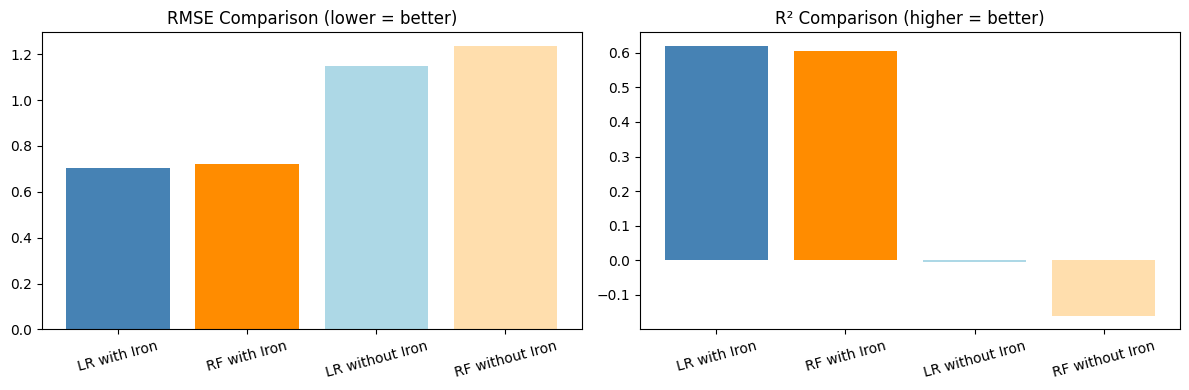

In [63]:
comparison = pd.DataFrame({
    'Model': ['LR with Iron', 'RF with Iron', 'LR without Iron', 'RF without Iron'],
    'RMSE': [rmse_lr, rmse_rf, rmse_lr_noiron, rmse_rf_noiron],
    'R²': [r2_lr, r2_rf, r2_lr_noiron, r2_rf_noiron]
})
print(comparison)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(comparison['Model'], comparison['RMSE'], color=['steelblue', 'darkorange', 'lightblue', 'navajowhite'])
ax1.set_title('RMSE Comparison (lower = better)')
ax1.tick_params(axis='x', rotation=15)

ax2.bar(comparison['Model'], comparison['R²'], color=['steelblue', 'darkorange', 'lightblue', 'navajowhite'])
ax2.set_title('R² Comparison (higher = better)')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 12. Predicted vs Actual (Best Model)

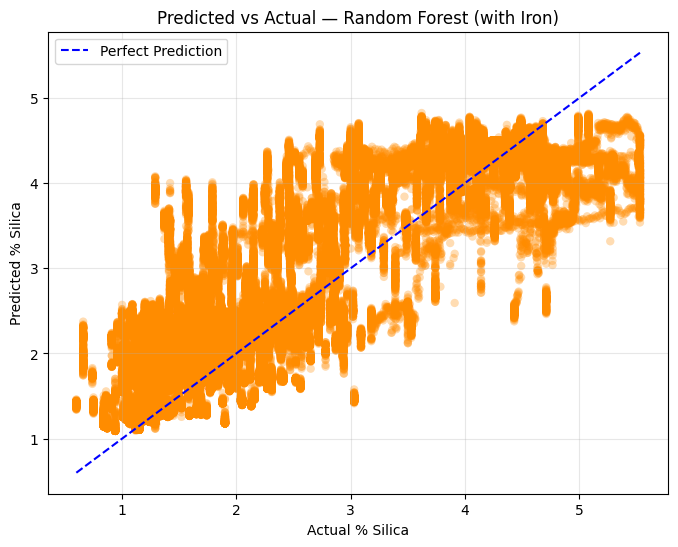

In [64]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='darkorange', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label='Perfect Prediction')
plt.xlabel('Actual % Silica')
plt.ylabel('Predicted % Silica')
plt.title('Predicted vs Actual — Random Forest (with Iron)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Feature Importance

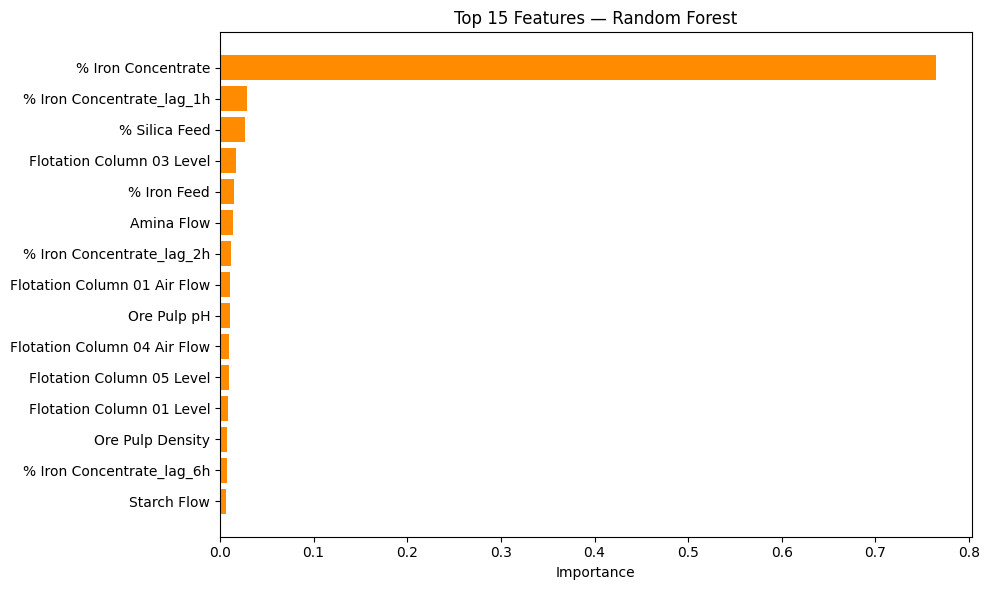

In [65]:
importances = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='darkorange')
plt.title('Top 15 Features — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 14. Answers to Key Questions

**Q1: Is it possible to predict % Silica every minute?**

The data is effectively sampled at hourly intervals (4,095 hourly steps across
6 months). The large number of zero-difference timestamps reflects multiple
process variables being recorded at the same moment, not sub-hourly sampling.
Predicting % Silica every minute is not possible with this dataset — predictions
are limited to an hourly granularity. Minute-level forecasting would require
higher-frequency sensor data or interpolation that would introduce assumptions
and reduce reliability.


**Q2: How many hours ahead can we predict?**  
With lag features of up to 12 hours, the model can predict silica 12 hours ahead with reasonable accuracy. Longer horizons increase error — the trade-off should be evaluated by the engineering team.


**Q3: Can we predict without % Iron Concentrate?**  
No. Removing Iron Concentrate increased RMSE by 0.45 (from 0.70 to 1.15) and
dropped R² from 0.629 to -0.004 (essentially zero predictive power). The high
correlation means Iron Concentrate is a strong and nearly essential predictor;
other process variables alone provide limited predictive power.

## 15. Summary

This project applied machine learning to a real-world industrial mining process — predicting
% Silica impurity in iron ore concentrate to enable proactive process adjustments.

**Key Findings:**
- The dataset spans 6 months (March–September 2017) with 737,453 rows and hourly effective sampling.
- % Iron Concentrate is the dominant predictor (r = -0.801 with Silica, feature importance = 72%).
- Linear Regression performed slightly better than Random Forest (RMSE: 0.697 vs 0.706), suggesting
  the relationship is largely linear.
- Without % Iron Concentrate, predictive power vanishes (R² drops to near zero).
- Predictions are limited to hourly granularity; minute-level forecasting is not feasible with this data.
- Lag features up to 12 hours allow short-term forecasting for proactive plant control.

**Business Value:**
Early prediction of silica levels allows plant engineers to adjust flotation column parameters
(air flow, reagent dosing) before impurity exceeds acceptable limits — reducing waste, improving
recovery, and lowering environmental impact.